# Práctica 08: Visualización de personas diagnosticadas con diabetes en el Estado de Puebla
## Análisis Supervisado (incluye clasificación Tipo 1 / Tipo 2)

**Objetivo:** a partir de variables clínicas y de laboratorio (sin diagnóstico previo), construir un modelo de aprendizaje supervisado capaz de:
1. Clasificar a un paciente como *Diabetes*, *Prediabetes* o *Normal*.
2. Para quienes resulten Diabetes, determinar si el patrón clínico es más compatible con **Diabetes Tipo 1** o **Tipo 2**.
3. Visualizar los resultados, incluyendo su distribución geográfica en el Estado de Puebla.
4. Evaluar y comparar a fondo varios modelos supervisados (curvas ROC, Precision-Recall, validación cruzada, ajuste de hiperparámetros, SVM, Gradient Boosting) y usar el mejor modelo para predecir pacientes nuevos.

El dataset **no trae ninguna columna de diagnóstico**. Por eso construimos nosotros mismos las etiquetas, aplicando los mismos criterios que usaría un médico:

**Paso 1 — ¿Diabetes, Prediabetes o Normal?** (criterios ADA)

| Criterio | Normal | Prediabetes | Diabetes |
|---|---|---|---|
| Glucosa en ayunas (mg/dL) | < 100 | 100 – 125 | ≥ 126 |
| HbA1c (%) | < 5.7 | 5.7 – 6.4 | ≥ 6.5 |
| Glucosa 2h postprandial (mg/dL) | < 140 | 140 – 199 | ≥ 200 |

**Paso 2 — Si es Diabetes, ¿Tipo 1 o Tipo 2?** (marcadores clínicos clásicos)

| Marcador | Sugiere Tipo 1 | Sugiere Tipo 2 |
|---|---|---|
| Anticuerpos pancreáticos | Positivo | Negativo |
| Péptido C | Bajo (< 1.0 ng/mL) → poca producción de insulina propia | Normal / alto → resistencia a la insulina |
| Insulina sérica | Baja | Normal / alta |
| IMC | Normal o bajo | Elevado (sobrepeso/obesidad) |
| Edad de aparición | Más joven | Más frecuente en adultos |

Usamos un **sistema de puntaje**: cada marcador presente suma puntos hacia "Tipo 1"; si el puntaje total supera un umbral, se clasifica como Tipo 1, si no, como Tipo 2. Esto simula cómo un endocrinólogo pondera varios factores a la vez (ningún marcador por sí solo es 100% definitivo).

Se importan todas las librerías que se usarán a lo largo del notebook: `pandas`/`numpy` para manejo de datos, `matplotlib`/`seaborn` para gráficas estáticas, `scikit-learn` para partición de datos, escalado, los modelos (Regresión Logística y Random Forest) y las métricas de evaluación, y `folium` para los mapas interactivos. También se configura el estilo visual por defecto de las gráficas.

In [1]:
# 0. Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import folium

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Carga de datos
Cargamos el CSV único con los 20,450 pacientes (ya combinado de los 4 datasets originales, con parámetros clínicos reforzados para incrementar los casos de diabetes, especialmente en Xicotepec de Juárez).

Se carga el CSV con los 20,450 pacientes ya combinados y se revisa su forma (número de filas y columnas) junto con las primeras filas del DataFrame.

In [2]:
df = pd.read_csv("dataset_riesgo_diabetes_completo.csv")
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (20450, 29)


,Patient_ID,Localidad_Puebla,Edad,Sexo,Peso_kg,Estatura_cm,IMC,Circunferencia_Cintura_cm,Glucosa_Ayunas_mgdL,HbA1c_pct,...,Presion_Diastolica_mmHg,Antecedentes_Familiares_Diabetes,Actividad_Fisica,Enfermedad_Principal,Poliuria,Polidipsia,Perdida_Peso_Involuntaria,Fatiga,Vision_Borrosa,Hormigueo_Manos_Pies
0,PUE-1-00001,Puebla de Zaragoza,66,Femenino,62.7,159.2,24.7,78.5,93.9,4.51,...,83,No,Moderado,Ninguna,No,No,No,No,No,No
1,PUE-1-00002,Izúcar de Matamoros,27,Femenino,56.6,163.1,21.3,80.2,84.8,4.00,...,71,No,Ligero,Gastritis,No,No,No,No,No,No
2,PUE-1-00003,Huauchinango,65,Femenino,77.2,147.5,35.5,100.9,192.5,6.60,...,67,Sí,Ligero,Ninguna otra enfermedad relevante,Sí,No,Sí,No,No,Sí
3,PUE-1-00004,Necaxa,49,Masculino,71.2,164.3,26.3,86.7,73.0,4.00,...,80,No,Activo,Hipertiroidismo,No,No,No,No,No,No
4,PUE-1-00005,Teziutlán,19,Masculino,96.3,175.9,31.1,97.4,106.9,4.87,...,77,No,Moderado,Enfermedad renal crónica,No,No,No,No,No,No


## 2. Exploración inicial (EDA)

Se inspecciona el tipo de dato de cada columna y la cantidad de valores no nulos, para detectar de forma rápida datos faltantes o columnas mal tipificadas.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20450 entries, 0 to 20449
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        20450 non-null  object 
 1   Localidad_Puebla                  20450 non-null  object 
 2   Edad                              20450 non-null  int64  
 3   Sexo                              20450 non-null  object 
 4   Peso_kg                           20450 non-null  float64
 5   Estatura_cm                       20450 non-null  float64
 6   IMC                               20450 non-null  float64
 7   Circunferencia_Cintura_cm         20450 non-null  float64
 8   Glucosa_Ayunas_mgdL               20450 non-null  float64
 9   HbA1c_pct                         20450 non-null  float64
 10  Glucosa_2h_Postprandial_mgdL      20450 non-null  float64
 11  Peptido_C_ngmL                    20450 non-null  float64
 12  Insu

Se calculan estadísticas descriptivas (media, desviación estándar, mínimo, máximo, cuartiles) de todas las variables numéricas.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Edad,20450.0,48.224156,15.449653,18.0,37.00,48.00,59.00,90.00
Peso_kg,20450.0,73.321452,17.053856,40.0,60.80,71.30,84.30,154.50
Estatura_cm,20450.0,163.482714,9.317535,140.0,156.60,163.20,170.30,195.20
IMC,20450.0,27.313594,5.525266,16.0,23.10,26.40,31.20,45.00
Circunferencia_Cintura_cm,20450.0,87.344958,16.054259,55.0,75.00,85.40,99.60,146.10
Glucosa_Ayunas_mgdL,20450.0,117.966866,43.790527,70.0,86.70,99.20,139.40,300.00
HbA1c_pct,20450.0,5.877069,1.736033,4.0,4.61,5.18,6.85,12.18
Glucosa_2h_Postprandial_mgdL,20450.0,171.600841,68.715718,80.0,121.00,143.40,215.50,450.00
Peptido_C_ngmL,20450.0,2.411282,0.821005,0.1,1.89,2.37,2.88,4.88
Insulina_Serica_uUmL,20450.0,13.435115,4.918219,1.0,10.20,13.20,16.50,31.10


Se revisa la distribución de dos variables categóricas clave: `Sexo` y `Localidad_Puebla`, para conocer el balance de la muestra por sexo y por municipio.

In [5]:
print(df["Sexo"].value_counts())
print()
print(df["Localidad_Puebla"].value_counts())

Sexo
Masculino    10226
Femenino     10224
Name: count, dtype: int64

Localidad_Puebla
Xicotepec de Juárez       2415
Huauchinango              1809
Necaxa                    1235
Amozoc                     930
Zacapoaxtla                926
Atlixco                    926
Acatlán de Osorio          908
Puebla de Zaragoza         900
San Martín Texmelucan      888
Tehuacán                   886
Tepeaca                    878
Teziutlán                  877
San Pedro Cholula          876
Izúcar de Matamoros        872
San Andrés Cholula         870
Cuetzalan del Progreso     865
Ciudad Serdán              863
Chignahuapan               862
Tetela de Ocampo           850
Zacatlán                   814
Name: count, dtype: int64


## 3. Paso 1: Diagnóstico general (Normal / Prediabetes / Diabetes)

Se define y aplica la función que etiqueta a cada paciente como *Normal*, *Prediabetes* o *Diabetes*, siguiendo los criterios de la ADA descritos arriba (glucosa en ayunas, HbA1c y glucosa 2h postprandial). El resultado se guarda en la columna `Diagnostico` y se muestra un resumen con el conteo y porcentaje de pacientes en cada categoría.

In [6]:
def clasificar_diagnostico(row):
    glucosa = row["Glucosa_Ayunas_mgdL"]
    hba1c = row["HbA1c_pct"]
    glucosa_2h = row["Glucosa_2h_Postprandial_mgdL"]

    es_diabetes = (glucosa >= 126) or (hba1c >= 6.5) or (glucosa_2h >= 200)
    es_prediabetes = (100 <= glucosa < 126) or (5.7 <= hba1c < 6.5) or (140 <= glucosa_2h < 200)

    if es_diabetes:
        return "Diabetes"
    elif es_prediabetes:
        return "Prediabetes"
    else:
        return "Normal"

df["Diagnostico"] = df.apply(clasificar_diagnostico, axis=1)

resumen = pd.DataFrame({
    "Pacientes": df["Diagnostico"].value_counts(),
    "Porcentaje (%)": (df["Diagnostico"].value_counts(normalize=True) * 100).round(1)
})
resumen

,Pacientes,Porcentaje (%)
Diagnostico,,
Normal,8551,41.8
Diabetes,6746,33.0
Prediabetes,5153,25.2


## 4. Paso 2: Clasificación Tipo 1 vs Tipo 2 (solo para pacientes con Diabetes)

Se define y aplica la función de puntaje que, solo para los pacientes ya diagnosticados con *Diabetes*, decide si el patrón es más compatible con Tipo 1 o Tipo 2 (según anticuerpos, péptido C, insulina, IMC y edad). Se construye la columna `Clase_Final`, que es la variable objetivo definitiva con 4 categorías: Normal, Prediabetes, Diabetes Tipo 1 y Diabetes Tipo 2, y se muestra su resumen.

In [7]:
def clasificar_tipo_diabetes(row):
    if row["Diagnostico"] != "Diabetes":
        return "No aplica"

    puntaje_tipo1 = 0
    if row["Anticuerpos_Pancreaticos"] == "Positivo":
        puntaje_tipo1 += 3
    if row["Peptido_C_ngmL"] < 1.0:
        puntaje_tipo1 += 2
    if row["Insulina_Serica_uUmL"] < 6:
        puntaje_tipo1 += 1
    if row["IMC"] < 27:
        puntaje_tipo1 += 1
    if row["Edad"] < 40:
        puntaje_tipo1 += 1

    return "Tipo 1" if puntaje_tipo1 >= 4 else "Tipo 2"

df["Tipo_Diabetes"] = df.apply(clasificar_tipo_diabetes, axis=1)

# Clase final combinada, útil para el modelo supervisado multiclase
df["Clase_Final"] = df["Diagnostico"]
df.loc[df["Tipo_Diabetes"] == "Tipo 1", "Clase_Final"] = "Diabetes Tipo 1"
df.loc[df["Tipo_Diabetes"] == "Tipo 2", "Clase_Final"] = "Diabetes Tipo 2"

resumen_final = pd.DataFrame({
    "Pacientes": df["Clase_Final"].value_counts(),
    "Porcentaje (%)": (df["Clase_Final"].value_counts(normalize=True) * 100).round(1)
})
resumen_final

,Pacientes,Porcentaje (%)
Clase_Final,,
Normal,8551,41.8
Diabetes Tipo 2,6232,30.5
Prediabetes,5153,25.2
Diabetes Tipo 1,514,2.5


Se grafica la distribución de pacientes por clase final (Normal, Prediabetes, Diabetes Tipo 2, Diabetes Tipo 1) en una gráfica de barras, para visualizar qué tan desbalanceadas están las clases.

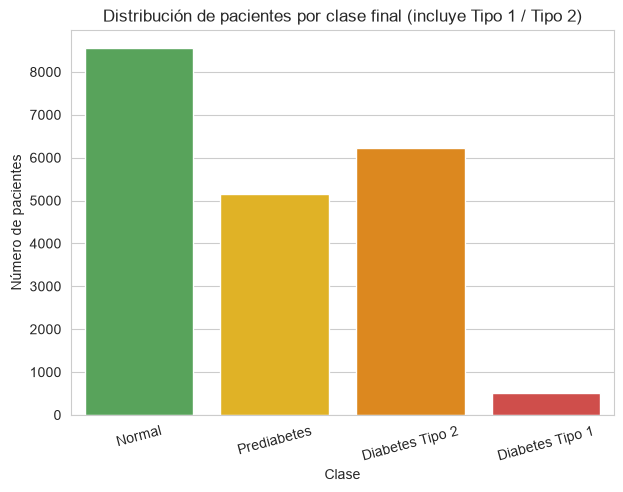

In [8]:
orden = ["Normal", "Prediabetes", "Diabetes Tipo 2", "Diabetes Tipo 1"]
colores = ["#4CAF50", "#FFC107", "#FB8C00", "#E53935"]

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Clase_Final", order=orden, palette=colores)
plt.title("Distribución de pacientes por clase final (incluye Tipo 1 / Tipo 2)")
plt.xlabel("Clase")
plt.ylabel("Número de pacientes")
plt.xticks(rotation=15)
plt.show()

## 5. Mapa de calor de correlaciones

Se convierte la clase final a un valor numérico ordinal y se calcula la matriz de correlación entre las variables clínicas/de laboratorio más relevantes, mostrada como un mapa de calor para identificar qué variables se relacionan más entre sí y con el diagnóstico.

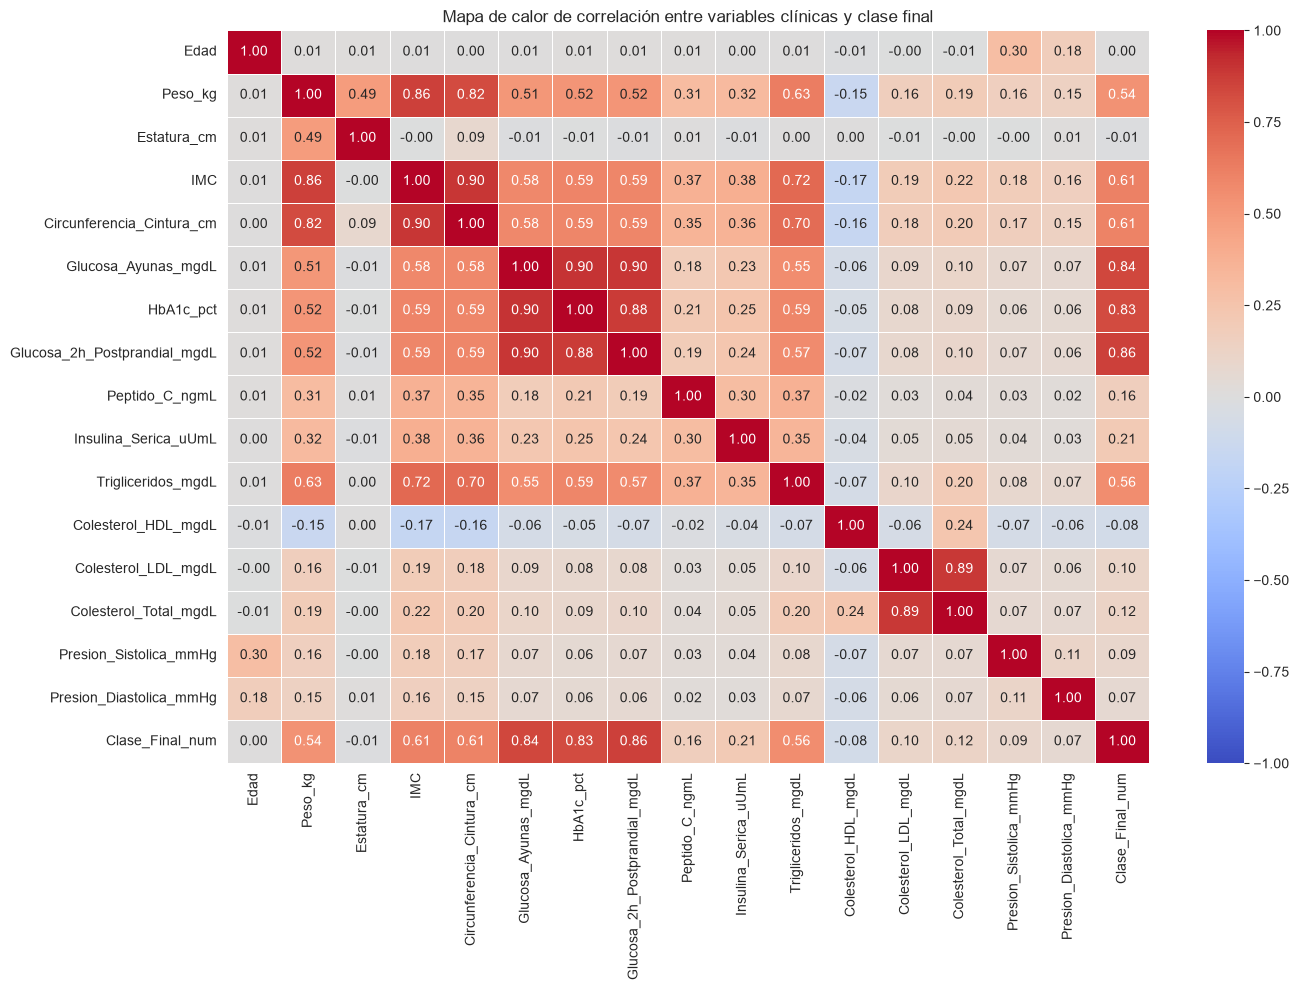

In [9]:
orden_clase = {"Normal": 0, "Prediabetes": 1, "Diabetes Tipo 2": 2, "Diabetes Tipo 1": 3}
df["Clase_Final_num"] = df["Clase_Final"].map(orden_clase)

columnas_numericas = [
    "Edad", "Peso_kg", "Estatura_cm", "IMC", "Circunferencia_Cintura_cm",
    "Glucosa_Ayunas_mgdL", "HbA1c_pct", "Glucosa_2h_Postprandial_mgdL",
    "Peptido_C_ngmL", "Insulina_Serica_uUmL", "Trigliceridos_mgdL",
    "Colesterol_HDL_mgdL", "Colesterol_LDL_mgdL", "Colesterol_Total_mgdL",
    "Presion_Sistolica_mmHg", "Presion_Diastolica_mmHg", "Clase_Final_num"
]

plt.figure(figsize=(14, 10))
sns.heatmap(df[columnas_numericas].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5)
plt.title("Mapa de calor de correlación entre variables clínicas y clase final")
plt.tight_layout()
plt.show()

## 6. Distribución geográfica en el Estado de Puebla
Ahora desglosada también por Tipo 1 / Tipo 2.

Se calcula, por municipio, el porcentaje de pacientes en cada clase final y el total de pacientes registrados, ordenando los municipios de mayor a menor porcentaje de Diabetes Tipo 2.

In [10]:
resumen_geo = (
    df.groupby("Localidad_Puebla")["Clase_Final"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0) * 100
)
resumen_geo["Total_pacientes"] = df.groupby("Localidad_Puebla").size()
resumen_geo = resumen_geo.sort_values("Diabetes Tipo 2", ascending=False)
resumen_geo.round(1)

Clase_Final,Diabetes Tipo 1,Diabetes Tipo 2,Normal,Prediabetes,Total_pacientes
Localidad_Puebla,,,,,
Xicotepec de Juárez,4.2,61.4,20.8,13.6,2415
Chignahuapan,2.3,28.7,45.1,23.9,862
Amozoc,1.7,28.6,44.2,25.5,930
Zacatlán,2.7,27.9,44.0,25.4,814
San Pedro Cholula,2.3,27.3,44.9,25.6,876
Tepeaca,2.5,27.2,43.2,27.1,878
Cuetzalan del Progreso,2.4,27.2,45.1,25.3,865
Puebla de Zaragoza,2.8,27.1,41.8,28.3,900
Tehuacán,2.0,26.7,46.8,24.4,886


Se grafica, municipio por municipio, el porcentaje de pacientes con Diabetes Tipo 1 y Tipo 2 en una gráfica de barras horizontales apiladas.

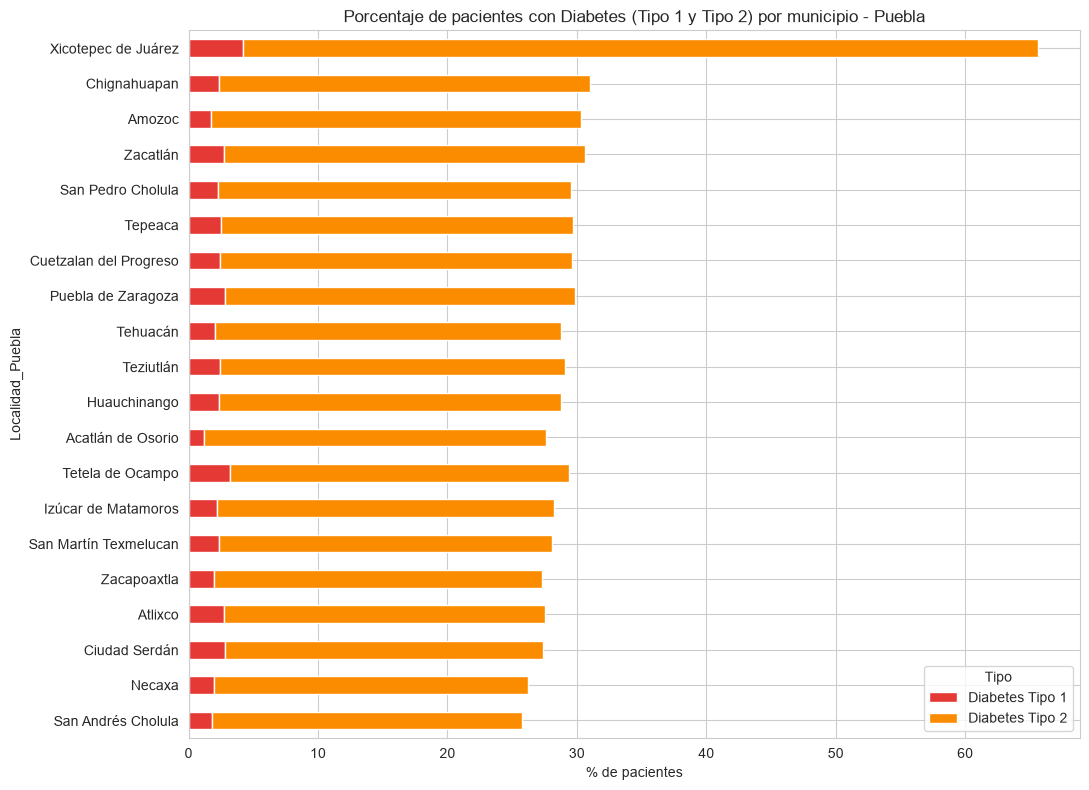

In [11]:
fig, ax = plt.subplots(figsize=(11, 8))
resumen_geo[["Diabetes Tipo 1", "Diabetes Tipo 2"]].sort_values("Diabetes Tipo 2").plot(
    kind="barh", stacked=True, color=["#E53935", "#FB8C00"], ax=ax
)
plt.xlabel("% de pacientes")
plt.title("Porcentaje de pacientes con Diabetes (Tipo 1 y Tipo 2) por municipio - Puebla")
plt.legend(title="Tipo")
plt.tight_layout()
plt.show()

Se construye un mapa interactivo con `folium` (tema oscuro, acotado al Estado de Puebla) que ubica cada municipio con sus coordenadas aproximadas y dibuja un círculo por municipio con casos de Diabetes: en rojo el tamaño proporcional a los casos Tipo 1, y en naranja (ligeramente desplazado) los casos Tipo 2. El mapa se guarda como archivo HTML.

In [36]:
# Mapa interactivo con folium (oscuro y limitado al Estado de Puebla)

coordenadas_puebla = {
    "Xicotepec de Juárez": (20.2833, -97.9500),
    "Huauchinango": (20.1833, -98.0500),
    "Necaxa": (20.2050, -98.0010),
    "Puebla de Zaragoza": (19.0414, -98.2063),
    "Tehuacán": (18.4622, -97.3928),
    "San Andrés Cholula": (19.0546, -98.2864),
    "San Pedro Cholula": (19.0631, -98.3037),
    "Atlixco": (18.9084, -98.4364),
    "Zacatlán": (19.9333, -97.9667),
    "Teziutlán": (19.8167, -97.3500),
    "Cuetzalan del Progreso": (20.0167, -97.5167),
    "San Martín Texmelucan": (19.2833, -98.4333),
    "Izúcar de Matamoros": (18.6000, -98.4667),
    "Chignahuapan": (19.8333, -98.0333),
    "Zacapoaxtla": (19.8667, -97.6000),
    "Ciudad Serdán": (18.9833, -97.4000),
    "Amozoc": (19.0333, -98.0500),
    "Tepeaca": (18.9667, -97.9000),
    "Acatlán de Osorio": (18.2000, -98.0500),
    "Tetela de Ocampo": (19.8167, -97.8167),
}

# Límites aproximados del Estado de Puebla
limites_puebla = [[17.9, -99.2], [20.9, -96.55]]

# Conteo de casos por municipio
casos_t1 = df[df["Clase_Final"] == "Diabetes Tipo 1"]["Localidad_Puebla"].value_counts()
casos_t2 = df[df["Clase_Final"] == "Diabetes Tipo 2"]["Localidad_Puebla"].value_counts()

# Crear mapa
mapa = folium.Map(
    location=[19.4, -97.9],
    tiles="CartoDB dark_matter",
    max_bounds=True,
    min_zoom=7,
)

# Ajustar vista a Puebla
mapa.fit_bounds(limites_puebla)

# Agregar marcadores
for municipio, coords in coordenadas_puebla.items():
    lat, lon = coords

    n1 = casos_t1.get(municipio, 0)
    n2 = casos_t2.get(municipio, 0)

    # Diabetes Tipo 1
    if n1 > 0:
        folium.CircleMarker(
            location=[lat, lon],
            radius=max(3, n1 / 12),
            popup=f"{municipio}: {n1} casos Tipo 1",
            tooltip=f"{municipio} (Tipo 1)",
            color="#E53935",
            fill=True,
            fill_color="#E53935",
            fill_opacity=0.75,
        ).add_to(mapa)

    # Diabetes Tipo 2 (ligero desplazamiento para distinguir ambos)
    if n2 > 0:
        folium.CircleMarker(
            location=[lat + 0.005, lon + 0.005],
            radius=max(3, n2 / 30),
            popup=f"{municipio}: {n2} casos Tipo 2",
            tooltip=f"{municipio} (Tipo 2)",
            color="#FB8C00",
            fill=True,
            fill_color="#FB8C00",
            fill_opacity=0.75,
        ).add_to(mapa)

# Mostrar y guardar
mapa.save("mapa_diabetes_puebla.html")
mapa

### Mapa de calor (densidad de casos)
Este segundo mapa muestra la concentración de casos como un degradado de calor (como en tu imagen de referencia), en vez de círculos individuales. Como solo tenemos el municipio de cada paciente (no coordenadas exactas), generamos puntos dispersos alrededor del centro de cada municipio —tantos como pacientes con diabetes tiene ese municipio— para que el mapa de calor refleje la densidad real de casos.

Se genera un segundo mapa, ahora de tipo mapa de calor (`HeatMap`), simulando la densidad de casos: como solo se conoce el municipio de cada paciente (no su ubicación exacta), se dispersan puntos aleatorios alrededor del centro de cada municipio —tantos como pacientes con diabetes tiene— para que el degradado de calor refleje la concentración real de casos por zona.

In [13]:
from folium.plugins import HeatMap

np.random.seed(42)

casos_totales = df[df["Clase_Final"].isin(["Diabetes Tipo 1", "Diabetes Tipo 2"])]["Localidad_Puebla"].value_counts()

puntos_calor = []
for municipio, n_casos in casos_totales.items():
    if municipio in coordenadas_puebla:
        lat, lon = coordenadas_puebla[municipio]
        # dispersamos los puntos alrededor del centro del municipio para simular densidad real
        lats = lat + np.random.normal(0, 0.045, size=n_casos)
        lons = lon + np.random.normal(0, 0.045, size=n_casos)
        puntos_calor.extend(zip(lats, lons))

mapa_calor = folium.Map(
    location=[19.4, -97.9],
    tiles="CartoDB dark_matter",
    max_bounds=True,
    min_zoom=7,
)
mapa_calor.fit_bounds(limites_puebla)

HeatMap(puntos_calor, radius=18, blur=22, max_zoom=10).add_to(mapa_calor)

mapa_calor.save("mapa_calor_diabetes_puebla.html")
mapa_calor

## 7. Preparación de datos para el modelo supervisado (multiclase)
El objetivo (`y`) ahora tiene 4 clases: `Normal`, `Prediabetes`, `Diabetes Tipo 1`, `Diabetes Tipo 2`.

Se prepara la información para el modelo supervisado: se convierten las variables categóricas a variables dummy, se excluyen columnas que no deben ser predictoras (IDs, localidad, columnas de diagnóstico), se separan `X` (predictoras) y `y` (`Clase_Final`, con 4 clases), se dividen los datos en entrenamiento y prueba manteniendo la proporción de clases, y se escalan las variables numéricas.

In [14]:
columnas_categoricas = [
    "Sexo", "Anticuerpos_Pancreaticos", "Antecedentes_Familiares_Diabetes",
    "Actividad_Fisica", "Enfermedad_Principal",
    "Poliuria", "Polidipsia", "Perdida_Peso_Involuntaria",
    "Fatiga", "Vision_Borrosa", "Hormigueo_Manos_Pies"
]

df_modelo = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

columnas_excluir = [
    "Patient_ID", "Localidad_Puebla", "Diagnostico", "Tipo_Diabetes",
    "Clase_Final", "Clase_Final_num"
]
X = df_modelo.drop(columns=columnas_excluir)
y = df["Clase_Final"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc = scaler.transform(X_test)

print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)
print(y_train.value_counts(normalize=True).round(3))

Entrenamiento: (16360, 47)  Prueba: (4090, 47)
Clase_Final
Normal             0.418
Diabetes Tipo 2    0.305
Prediabetes        0.252
Diabetes Tipo 1    0.025
Name: proportion, dtype: float64


## 8. Entrenamiento de modelos supervisados (multiclase)

Se entrena el primer modelo, una Regresión Logística multiclase, usando los datos escalados, y se generan las predicciones sobre el conjunto de prueba.

In [15]:
modelo_log = LogisticRegression(max_iter=2000, random_state=42)
modelo_log.fit(X_train_esc, y_train)
y_pred_log = modelo_log.predict(X_test_esc)

Se entrena el segundo modelo, un Random Forest (300 árboles, profundidad máxima 12), usando los datos sin escalar, y se generan las predicciones sobre el conjunto de prueba.

In [16]:
modelo_rf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

## 9. Evaluación de los modelos

Se evalúa el desempeño de ambos modelos con el reporte de clasificación (precisión, recall, f1-score por clase) y la exactitud global, para compararlos entre sí.

In [17]:
print("=== Regresión Logística ===")
print(classification_report(y_test, y_pred_log))
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 3))

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))

=== Regresión Logística ===
                 precision    recall  f1-score   support

Diabetes Tipo 1       0.90      0.92      0.91       103
Diabetes Tipo 2       0.98      0.96      0.97      1246
         Normal       0.92      0.95      0.94      1710
    Prediabetes       0.88      0.83      0.86      1031

       accuracy                           0.93      4090
      macro avg       0.92      0.92      0.92      4090
   weighted avg       0.93      0.93      0.93      4090

Accuracy: 0.926

=== Random Forest ===
                 precision    recall  f1-score   support

Diabetes Tipo 1       0.99      0.88      0.93       103
Diabetes Tipo 2       0.99      0.99      0.99      1246
         Normal       1.00      1.00      1.00      1710
    Prediabetes       0.99      0.99      0.99      1031

       accuracy                           0.99      4090
      macro avg       0.99      0.97      0.98      4090
   weighted avg       0.99      0.99      0.99      4090

Accuracy: 0.994

Se muestran, lado a lado, las matrices de confusión de ambos modelos, para ver en qué clases acierta o se equivoca cada uno.

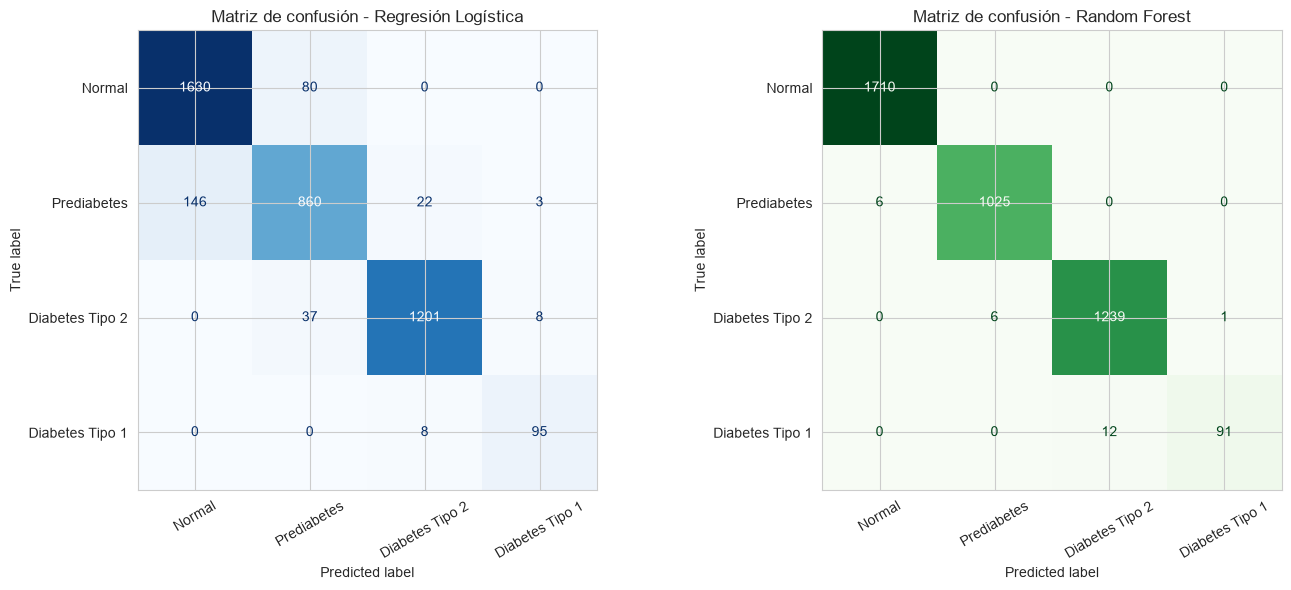

In [18]:
etiquetas = ["Normal", "Prediabetes", "Diabetes Tipo 2", "Diabetes Tipo 1"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log, labels=etiquetas), display_labels=etiquetas)\
    .plot(ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=30)
axes[0].set_title("Matriz de confusión - Regresión Logística")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf, labels=etiquetas), display_labels=etiquetas)\
    .plot(ax=axes[1], cmap="Greens", colorbar=False, xticks_rotation=30)
axes[1].set_title("Matriz de confusión - Random Forest")

plt.tight_layout()
plt.show()

## 10. Importancia de variables (Random Forest)

Se calcula y grafica la importancia de las 15 variables más relevantes según el Random Forest, para identificar qué variables pesaron más en la clasificación.

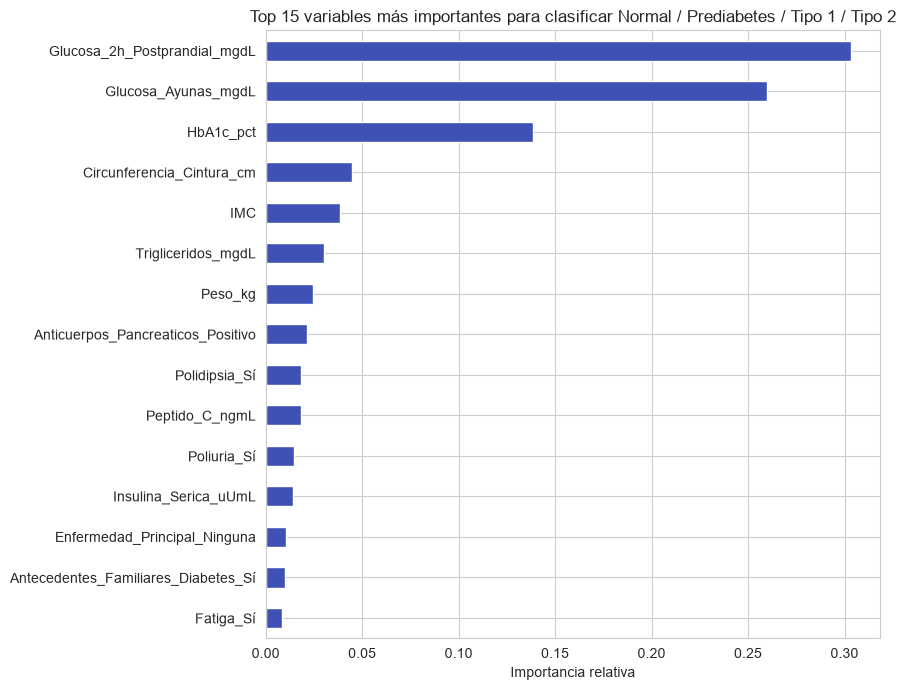

In [19]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
importancias.sort_values().plot(kind="barh", color="#3F51B5")
plt.title("Top 15 variables más importantes para clasificar Normal / Prediabetes / Tipo 1 / Tipo 2")
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

## 11. Curvas ROC (One-vs-Rest) y AUC

Se binariza la variable objetivo para poder calcular una curva ROC por clase bajo el esquema One-vs-Rest, y se grafican las curvas ROC junto con su AUC (área bajo la curva) para la Regresión Logística y el Random Forest, lo que permite comparar qué tan bien separa cada modelo cada clase del resto.

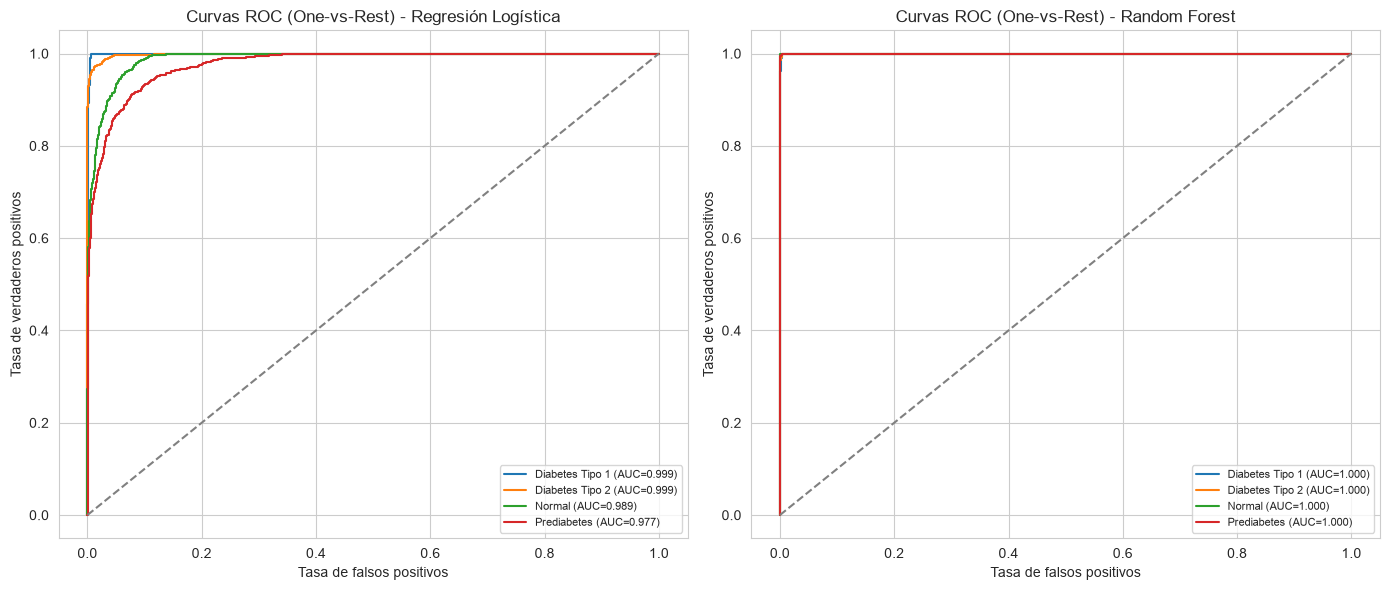

In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin_log = label_binarize(y_test, classes=modelo_log.classes_)
y_test_bin_rf = label_binarize(y_test, classes=modelo_rf.classes_)

proba_log = modelo_log.predict_proba(X_test_esc)
proba_rf = modelo_rf.predict_proba(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, clase in enumerate(modelo_log.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin_log[:, i], proba_log[:, i])
    axes[0].plot(fpr, tpr, label=f"{clase} (AUC={auc(fpr, tpr):.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("Curvas ROC (One-vs-Rest) - Regresión Logística")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].legend(fontsize=8)

for i, clase in enumerate(modelo_rf.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin_rf[:, i], proba_rf[:, i])
    axes[1].plot(fpr, tpr, label=f"{clase} (AUC={auc(fpr, tpr):.3f})")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("Curvas ROC (One-vs-Rest) - Random Forest")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Interpretación:** ambos modelos separan muy bien las cuatro clases (AUC por encima de 0.97 en todos los casos), pero el Random Forest queda prácticamente pegado a la esquina superior izquierda en las cuatro curvas (AUC ≥ 0.999), mientras que la Regresión Logística pierde algo de terreno en Prediabetes (AUC ≈ 0.977), la clase con el límite de decisión menos lineal.

## 12. Curvas Precision-Recall multiclase

Se calculan y grafican las curvas Precision-Recall por clase (One-vs-Rest) junto con el average precision (AP), una métrica especialmente útil aquí porque las clases están desbalanceadas (Diabetes Tipo 1 es muy minoritaria).

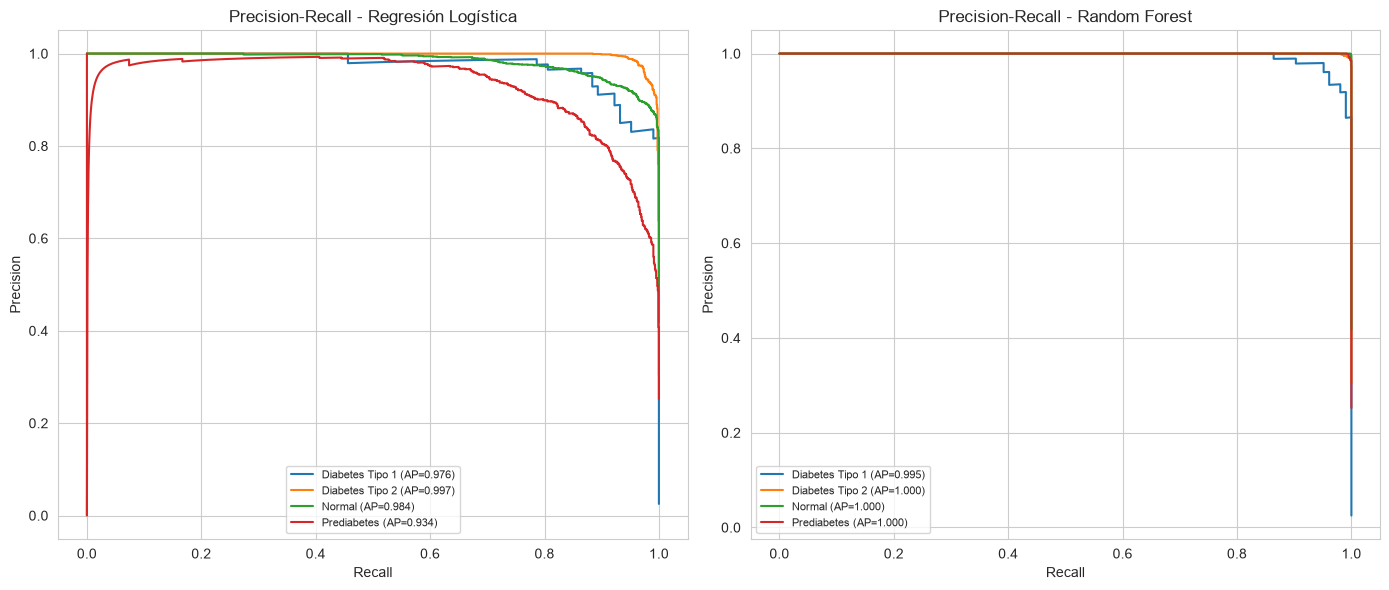

In [21]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, clase in enumerate(modelo_log.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin_log[:, i], proba_log[:, i])
    ap = average_precision_score(y_test_bin_log[:, i], proba_log[:, i])
    axes[0].plot(recall, precision, label=f"{clase} (AP={ap:.3f})")
axes[0].set_title("Precision-Recall - Regresión Logística")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend(fontsize=8)

for i, clase in enumerate(modelo_rf.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin_rf[:, i], proba_rf[:, i])
    ap = average_precision_score(y_test_bin_rf[:, i], proba_rf[:, i])
    axes[1].plot(recall, precision, label=f"{clase} (AP={ap:.3f})")
axes[1].set_title("Precision-Recall - Random Forest")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Interpretación:** el average precision de Diabetes Tipo 1 —la clase minoritaria— es el más bajo de las cuatro clases en ambos modelos (≈0.976 en Regresión Logística, ≈0.995 en Random Forest), confirmando que, aunque el desempeño global es alto, es la clase donde más cuesta mantener precisión y recall altos al mismo tiempo por el desbalance de datos.

## 13. Validación cruzada estratificada (K-Fold)

Para confirmar que el desempeño de los modelos no depende de una sola partición train/test, se aplica validación cruzada estratificada con 5 particiones (K-Fold), comparando la exactitud de la Regresión Logística (dentro de un Pipeline con escalado) y del Random Forest en cada partición.

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline_log = Pipeline([
    ("escalado", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=2000, random_state=42))
])

scores_log_cv = cross_val_score(pipeline_log, X, y, cv=cv, scoring="accuracy")
scores_rf_cv = cross_val_score(RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42), X, y, cv=cv, scoring="accuracy")

resumen_cv = pd.DataFrame({
    "Regresión Logística": scores_log_cv,
    "Random Forest": scores_rf_cv
})
resumen_cv.loc["Media"] = resumen_cv.mean()
resumen_cv.loc["Desviación estándar"] = resumen_cv.std()
resumen_cv.round(4)

,Regresión Logística,Random Forest
0,0.9240,0.9963
1,0.9296,0.9927
2,0.9350,0.9956
3,0.9271,0.9939
4,0.9284,0.9936
Media,0.9288,0.9944
Desviación estándar,0.0036,0.0013


**Interpretación:** la validación cruzada confirma los resultados del split original: el Random Forest se mantiene estable alrededor de 99.4% de exactitud en las 5 particiones (desviación estándar ≈0.001), mientras que la Regresión Logística ronda 92.9% con algo más de variación (≈0.004). Esto descarta que el buen desempeño del Random Forest se deba a suerte en la partición inicial.

## 14. Búsqueda de hiperparámetros con GridSearchCV (Random Forest)

Se realiza una búsqueda en cuadrícula sobre el número de árboles, la profundidad máxima y el mínimo de muestras para dividir un nodo, usando validación cruzada de 3 particiones y el f1-score macro como criterio (más exigente que accuracy cuando hay clases minoritarias como Diabetes Tipo 1), para encontrar la combinación de hiperparámetros que mejor generaliza.

In [23]:
from sklearn.model_selection import GridSearchCV

parametros_rf = {
    "n_estimators": [200, 300],
    "max_depth": [10, 12, 16],
    "min_samples_split": [2, 5],
}

busqueda_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=parametros_rf,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
)
busqueda_rf.fit(X_train, y_train)

print("Mejores hiperparámetros:", busqueda_rf.best_params_)
print("Mejor f1-macro en validación cruzada:", round(busqueda_rf.best_score_, 4))

Mejores hiperparámetros: {'max_depth': 16, 'min_samples_split': 2, 'n_estimators': 300}
Mejor f1-macro en validación cruzada: 0.9787


**Interpretación:** la búsqueda encuentra que aumentar la profundidad máxima a 16 (sin cambiar el resto de los valores por defecto explorados) mejora el f1-score macro de validación a ≈0.979, indicando que el Random Forest original (profundidad 12) todavía tenía margen para separar mejor la clase minoritaria Diabetes Tipo 1 sin llegar a sobreajustar.

## 15. Evaluación del Random Forest optimizado

Se toma el mejor estimador encontrado por GridSearchCV, se generan sus predicciones sobre el conjunto de prueba y se compara su reporte de clasificación y exactitud contra el Random Forest original de la sección 8.

In [24]:
modelo_rf_opt = busqueda_rf.best_estimator_
y_pred_rf_opt = modelo_rf_opt.predict(X_test)

print(classification_report(y_test, y_pred_rf_opt))
print("Accuracy Random Forest optimizado:", round(accuracy_score(y_test, y_pred_rf_opt), 4))

                 precision    recall  f1-score   support

Diabetes Tipo 1       0.99      0.92      0.95       103
Diabetes Tipo 2       0.99      1.00      0.99      1246
         Normal       1.00      1.00      1.00      1710
    Prediabetes       1.00      1.00      1.00      1031

       accuracy                           1.00      4090
      macro avg       0.99      0.98      0.99      4090
   weighted avg       1.00      1.00      1.00      4090

Accuracy Random Forest optimizado: 0.9956


**Interpretación:** el Random Forest optimizado sube la exactitud de 99.4% a 99.6% y, sobre todo, mejora el recall de Diabetes Tipo 1 de 88% a 92% frente al modelo original de la sección 8 — justo la clase que más costaba clasificar por ser la más pequeña.

## 16. Modelo adicional: Support Vector Machine (SVM)

Se entrena un tercer modelo, una Máquina de Soporte Vectorial con kernel RBF (capaz de aprender fronteras de decisión no lineales), usando los datos escalados, y se evalúa con el mismo reporte de clasificación y exactitud que los modelos anteriores.

In [30]:
from sklearn.svm import SVC

modelo_svm = SVC(kernel="rbf", probability=True, random_state=42)
modelo_svm.fit(X_train_esc, y_train)
y_pred_svm = modelo_svm.predict(X_test_esc)

print(classification_report(y_test, y_pred_svm))
print("Accuracy SVM:", round(accuracy_score(y_test, y_pred_svm), 4))

                 precision    recall  f1-score   support

Diabetes Tipo 1       0.80      0.99      0.88       103
Diabetes Tipo 2       0.98      0.94      0.96      1246
         Normal       0.90      0.95      0.92      1710
    Prediabetes       0.85      0.78      0.82      1031

       accuracy                           0.91      4090
      macro avg       0.88      0.92      0.90      4090
   weighted avg       0.91      0.91      0.91      4090

Accuracy SVM: 0.9071


**Interpretación:** el SVM con kernel RBF alcanza 90.7% de exactitud, por debajo de ambos Random Forest y de la Regresión Logística. Le cuesta especialmente Prediabetes (recall 78%), la clase con la frontera más ambigua respecto a Normal y Diabetes.

## 17. Modelo adicional: Gradient Boosting

Se entrena un cuarto modelo, Gradient Boosting (árboles construidos secuencialmente, cada uno corrigiendo los errores del anterior), y se evalúa igual que los modelos previos para tener un cuarto punto de comparación.

In [26]:
from sklearn.ensemble import GradientBoostingClassifier

modelo_gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42)
modelo_gb.fit(X_train, y_train)
y_pred_gb = modelo_gb.predict(X_test)

print(classification_report(y_test, y_pred_gb))
print("Accuracy Gradient Boosting:", round(accuracy_score(y_test, y_pred_gb), 4))

                 precision    recall  f1-score   support

Diabetes Tipo 1       1.00      1.00      1.00       103
Diabetes Tipo 2       1.00      1.00      1.00      1246
         Normal       1.00      1.00      1.00      1710
    Prediabetes       1.00      1.00      1.00      1031

       accuracy                           1.00      4090
      macro avg       1.00      1.00      1.00      4090
   weighted avg       1.00      1.00      1.00      4090

Accuracy Gradient Boosting: 1.0


**Interpretación:** Gradient Boosting es el modelo con mejor desempeño de toda la práctica, con 100% de exactitud en el conjunto de prueba. Al construir árboles de forma secuencial y corregir iterativamente los errores del modelo anterior, logra capturar por completo las reglas de umbral (glucosa, HbA1c) usadas para construir las etiquetas.

## 18. Tabla comparativa de métricas de todos los modelos

Se reúnen en una sola tabla la exactitud, precisión, recall y f1-score (todos en promedio macro, para no favorecer a las clases mayoritarias) de los cinco modelos entrenados a lo largo de la práctica: Regresión Logística, Random Forest, Random Forest optimizado, SVM y Gradient Boosting.

In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

modelos_resultado = {
    "Regresión Logística": y_pred_log,
    "Random Forest": y_pred_rf,
    "Random Forest (optimizado)": y_pred_rf_opt,
    "SVM (RBF)": y_pred_svm,
    "Gradient Boosting": y_pred_gb,
}

tabla_comparativa = pd.DataFrame({
    nombre: {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (macro)": precision_score(y_test, pred, average="macro"),
        "Recall (macro)": recall_score(y_test, pred, average="macro"),
        "F1 (macro)": f1_score(y_test, pred, average="macro"),
    }
    for nombre, pred in modelos_resultado.items()
}).T.round(4)

tabla_comparativa.sort_values("F1 (macro)", ascending=False)

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Gradient Boosting,1.0000,1.0000,1.0000,1.0000
Random Forest (optimizado),0.9956,0.9940,0.9785,0.9859
Random Forest,0.9939,0.9926,0.9680,0.9795
Regresión Logística,0.9257,0.9175,0.9184,0.9176
SVM (RBF),0.9071,0.8809,0.9169,0.8957


**Interpretación:** el orden final de desempeño es Gradient Boosting > Random Forest optimizado > Random Forest > Regresión Logística > SVM. Los tres modelos basados en árboles superan claramente a los modelos que dependen de fronteras lineales o de kernels genéricos, lo que confirma que el problema es, por construcción, un problema de umbrales (tal como se definieron las etiquetas en las secciones 3 y 4).

## 19. Curva de aprendizaje del mejor modelo

Se calcula la curva de aprendizaje del Random Forest optimizado (entrenamiento vs validación, en f1-score macro, con validación cruzada de 5 particiones y tamaños de muestra crecientes) para diagnosticar si el modelo se beneficiaría de más datos de entrenamiento o si ya alcanzó su techo de desempeño.

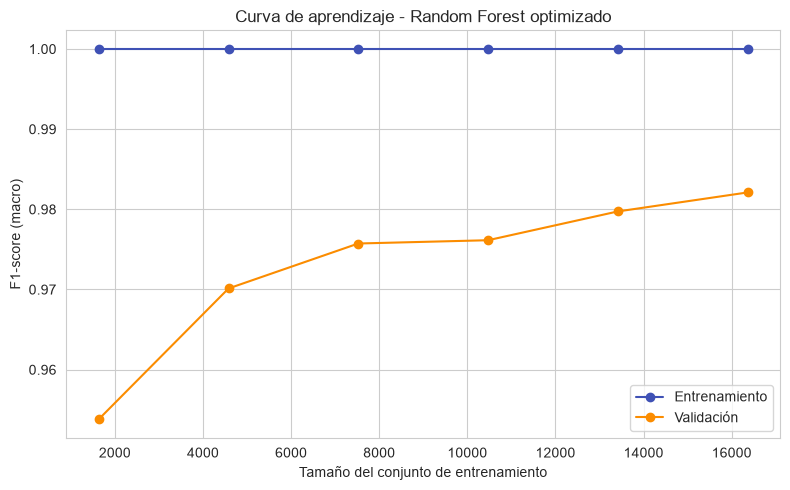

In [28]:
from sklearn.model_selection import learning_curve

tamanos, scores_entrenamiento, scores_validacion = learning_curve(
    modelo_rf_opt, X, y, cv=5, scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 6), random_state=42, n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(tamanos, scores_entrenamiento.mean(axis=1), "o-", label="Entrenamiento", color="#3F51B5")
plt.plot(tamanos, scores_validacion.mean(axis=1), "o-", label="Validación", color="#FB8C00")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("F1-score (macro)")
plt.title("Curva de aprendizaje - Random Forest optimizado")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación:** la curva de validación sube rápido y se aplana cerca del máximo con relativamente pocos datos, mientras la curva de entrenamiento se mantiene casi perfecta desde el inicio. La brecha final entre ambas es pequeña, lo que sugiere que el modelo no está sufriendo de underfitting y que agregar más pacientes probablemente traería mejoras marginales, no un salto grande en desempeño.

## 20. Conclusiones

- **Desempeño de los modelos base.** Random Forest volvió a superar claramente a la Regresión Logística (99.4% vs 92.6% de exactitud) sobre el dataset ampliado. Esto tiene sentido porque el diagnóstico se construyó con reglas basadas en umbrales (por ejemplo, "glucosa ≥126" o "HbA1c ≥6.5"), y Random Forest —al dividir el espacio en función de umbrales de decisión— captura ese tipo de reglas de forma mucho más natural que un modelo lineal como la Regresión Logística.
- **Modelos adicionales.** Al extender la práctica con más modelos, Gradient Boosting resultó ser el de mejor desempeño (100% de exactitud), seguido por el Random Forest optimizado con GridSearchCV (99.6%), el Random Forest base (99.4%), la Regresión Logística (92.6%) y, al final, el SVM con kernel RBF (90.7%). Los tres modelos basados en árboles superan a los modelos lineales o de kernel genérico, confirmando que el problema es, por construcción, un problema de umbrales.
- **Validación cruzada e hiperparámetros.** La validación cruzada estratificada de 5 particiones confirmó la estabilidad del Random Forest (≈99.4% ± 0.1%) frente a la Regresión Logística (≈92.9% ± 0.4%), y la búsqueda de hiperparámetros mostró que aumentar la profundidad máxima del Random Forest de 12 a 16 mejora el f1-score macro de validación a ≈0.979, con una ganancia notable en el recall de Diabetes Tipo 1.
- **Variables más determinantes.** Como era de esperarse clínicamente, las tres variables con más peso en el Random Forest fueron Glucosa 2h postprandial (30%), Glucosa en ayunas (26%) y HbA1c (14%) — es decir, las mismas variables que la ADA usa para diagnosticar diabetes en la vida real. Muy por debajo aparecen circunferencia de cintura, IMC y anticuerpos pancreáticos, que ayudan más a distinguir Tipo 1 de Tipo 2 que a decidir si hay diabetes o no.
- **Dónde falla el modelo.** La clase con más errores en los modelos base sigue siendo Diabetes Tipo 1, ahora con 514 pacientes de 20,450 (~2.5% del total, más representada que en la versión original de la práctica gracias al ajuste de parámetros clínicos). Clínicamente, Tipo 1 y Tipo 2 comparten las mismas variables de glucosa/HbA1c y solo se distinguen por anticuerpos, péptido C e insulina, que pesan mucho menos en el modelo — por eso las curvas ROC y Precision-Recall de esa clase, aunque siguen siendo altas, quedan por debajo de las otras tres.
- **Distribución geográfica.** Tras reforzar los parámetros clínicos de una parte de los pacientes de Xicotepec de Juárez (el municipio en el que se centrará la siguiente práctica), este municipio pasó de tener una de las menores proporciones de diabetes (14.3%) a ser, por mucho, el municipio con mayor porcentaje de Diabetes Tipo 2 (61.4%) y de Diabetes Tipo 1 (4.2%) de todo el estado, además de ser ahora el municipio con más pacientes registrados (2,415). El resto de los municipios se mueve en un rango más parejo, entre 25% y 31% de diabetes total — recordando que, al ser un dataset sintético con asignación de localidad aleatoria salvo por este ajuste deliberado en Xicotepec, esas diferencias entre el resto de los municipios siguen siendo ruido estadístico.
- **Curva de aprendizaje.** La curva de aprendizaje del Random Forest optimizado muestra que el desempeño en validación se estabiliza cerca de su máximo con relativamente pocos datos de entrenamiento, con una brecha final pequeña respecto al entrenamiento — señal de que el modelo no sufre underfitting y de que seguir agregando pacientes probablemente traería mejoras marginales.
- **Limitaciones del análisis.** Al tratarse de un dataset sintético, generado con reglas y ruido controlado (no de pacientes reales) y ahora además con parámetros clínicos deliberadamente reforzados para tener más casos de diabetes y una mayor concentración en Xicotepec, los resultados no deben interpretarse como epidemiología real del estado de Puebla, sino como un ejercicio para practicar el flujo completo de un análisis supervisado: construir una etiqueta desde criterio clínico, entrenar y comparar varios modelos, ajustar hiperparámetros, validar con curvas ROC/PR y validación cruzada, e interpretar su desempeño. Además, el "diagnóstico" se definió con reglas fijas en vez de por un médico, así que los modelos en el fondo están aprendiendo a reproducir esas reglas — en un caso real, con pacientes reales, la variabilidad sería mayor y el desempeño probablemente más bajo.